In [36]:
import numpy as np
import pandas as pd

import time
from pathlib import Path
from urllib.request import urlopen

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import clear_output
from pandas.core import sample
from torch.nn.modules import distance

In [37]:
HELPER_UTILS_URL = "https://raw.githubusercontent.com/cbtn-data-science-ml/introduction-to-machine-learning-and-ai-engineering/refs/heads/main/helper_utils.py"

helper_code = urlopen(HELPER_UTILS_URL).read().decode("utf-8")
Path("helper_utils.py").write_text(helper_code)

import helper_utils

In [38]:
distance_miles = [ 1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  5.5,  6. ,
        6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5, 11. , 11.5,
       12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 16. , 16.5, 17. ,
       17.5, 18. , 18.5, 19. , 19.5, 20. ]

delivery_time = [
    13.65, 16.45, 21.44, 27.26, 27.98, 31.89, 39.04, 41.47, 43.15, 48.88,
    55.74, 56.56, 59.77, 57.06, 58.90, 62.48, 63.18, 67.08, 66.37, 66.96,
    73.64, 72.09, 74.18, 72.94, 76.02, 78.70, 77.93, 82.18, 82.91, 83.97,
    84.92, 90.83, 88.92, 88.60, 93.48, 91.78, 95.38, 92.87, 95.61
]

In [39]:
distance = torch.tensor(distance_miles, dtype=torch.float32).reshape(-1, 1)
times = torch.tensor(delivery_time, dtype=torch.float32).reshape(-1, 1)

In [40]:
distance.shape # before reshape:(39,) after reshape:(39, 1)

torch.Size([39, 1])

In [41]:
times.shape

torch.Size([39, 1])

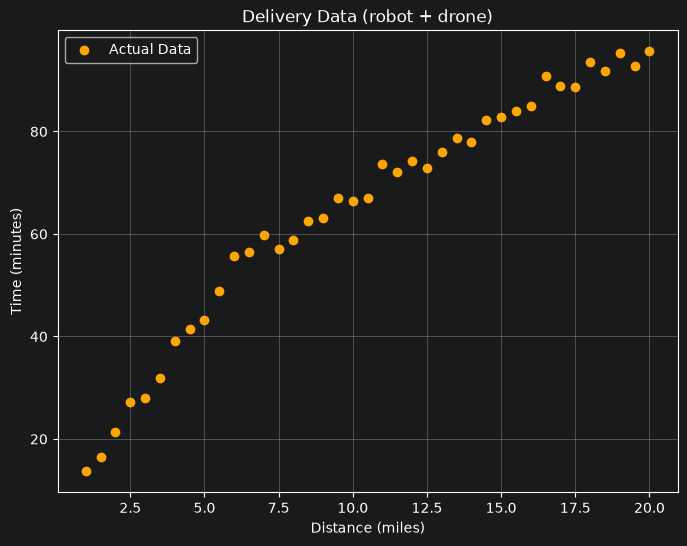

In [42]:
helper_utils.plot_points(
    distance,
    times,
    title="Delivery Data (robot + drone)",
    label="Actual Data",
)

In [43]:
torch.manual_seed(42)


linear_model = nn.Sequential(nn.Linear(1, 1))
linear_loss_function = nn.MSELoss()
linear_optimizer = optim.SGD(linear_model.parameters(), lr=0.001)
linear_loss = None
linear_train_losses = []

for epoch in range(3000):
    linear_optimizer.zero_grad()
    linear_outputs = linear_model(distance)
    linear_loss = linear_loss_function(linear_outputs, times)
    linear_loss.backward()
    linear_optimizer.step()
    linear_train_losses.append(linear_loss.item())
print("Final linear baseline loss: ", linear_loss.item())

Final linear baseline loss:  36.61886215209961


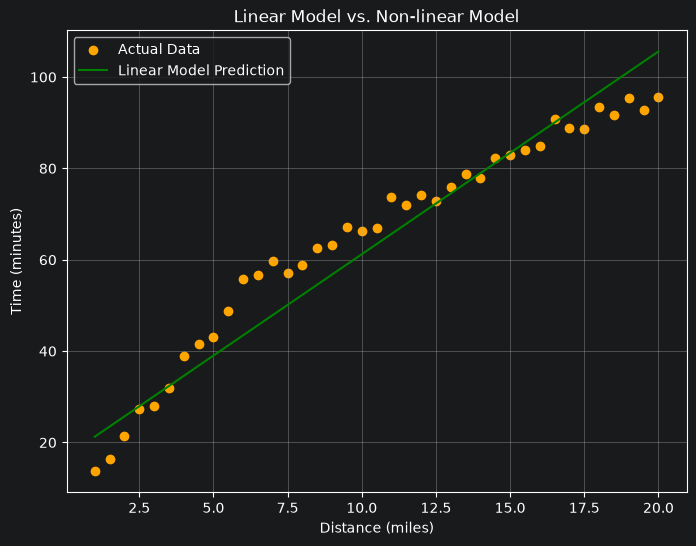

In [44]:
with torch.no_grad():
    linear_predictions = linear_model(distance)
helper_utils.plot_fit(
    distance,
    times,
    linear_predictions,
    title="Linear Model vs. Non-linear Model",
    data_label="Actual Data",
    pred_label="Linear Model Prediction",
)

In [45]:
distances_mean = distance.mean()
distances_std = distance.std()

times_mean = times.mean()
times_std = times.std()

distances_norm = (distance - distances_mean) / distances_std
times_norm = (times - times_mean) / times_std


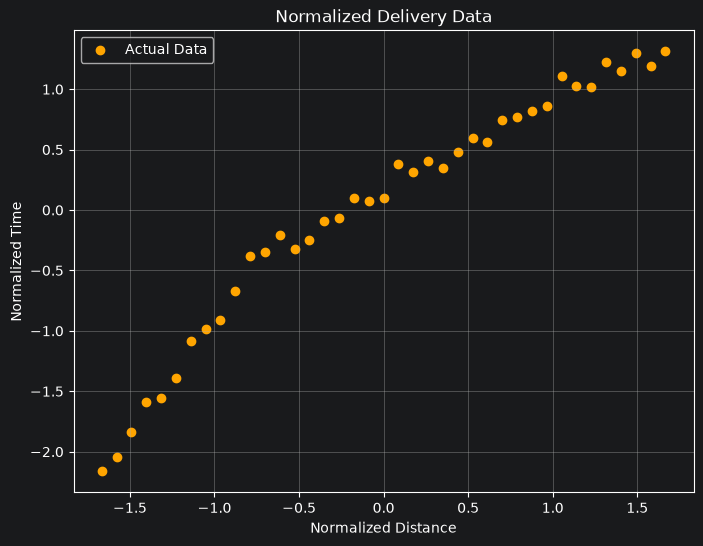

In [46]:
helper_utils.plot_points(
    distances_norm,
    times_norm,
    normalized=True,
    title="Normalized Delivery Data",
)

In [47]:
torch.manual_seed(42)

model = nn.Sequential(
    nn.Linear(1, 3),
    nn.ReLU(),
    nn.Linear(3, 1),
)

print(model)

Sequential(
  (0): Linear(in_features=1, out_features=3, bias=True)
  (1): ReLU()
  (2): Linear(in_features=3, out_features=1, bias=True)
)


In [48]:
sample_values = torch.tensor([[-2.0],[-0.5],[1.0],[3.0],])
relu = nn.ReLU()
relu_outputs = relu(sample_values)

In [49]:
sample_values

tensor([[-2.0000],
        [-0.5000],
        [ 1.0000],
        [ 3.0000]])

In [50]:
relu_outputs

tensor([[0.],
        [0.],
        [1.],
        [3.]])

In [51]:
loss_function = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)

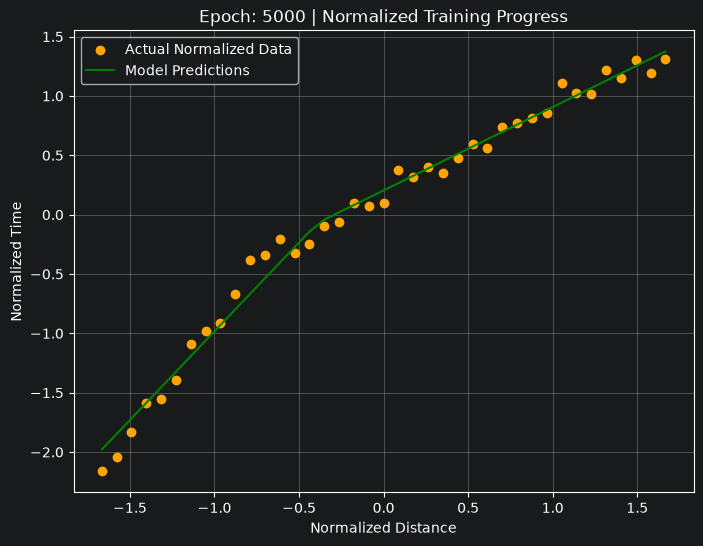

Training Complete
Final Loss:  0.010975554585456848


In [52]:
torch.manual_seed(42)
num_epochs = 5000
train_losses = []

for epoch in range(num_epochs):
    optimizer.zero_grad()
    outputs = model(distances_norm)
    loss = loss_function(outputs, times_norm)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    if (epoch + 1) % 50 == 0:
        helper_utils.plot_training_progress(
            epoch,
            model,
            distances_norm,
            times_norm,
        )
    print("Training Complete")
    print("Final Loss: ", loss.item())